# 17-Qubit Distance-3 Surface Code Processor (Wallraff style)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/tutorials%2FAppendix%20C%20Circuit%20examples%2FF.%20Small-quantum-chips%2F53-Walraff_17Qubit_SurfaceCode.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=tutorials%2FAppendix%20C%20Circuit%20examples%2FF.%20Small-quantum-chips%2F53-Walraff_17Qubit_SurfaceCode.ipynb)

> 💡 **Running in Colab or Binder?** Uncomment the install cell below.

Reproduces the topology and qubit placement of the 17-qubit distance-3 rotated surface-code processor from the Quantum Device Lab, ETH Zürich (Andreas Wallraff's group): 9 data qubits (D1–D9) and 8 syndrome-measurement ancillas (X1–X4, Z1–Z4), each with its own readout resonator, XY drive line, and Z flux line. See Krinner *et al.*, ["Realizing repeated quantum error correction in a distance-three surface code"](https://doi.org/10.1038/s41586-022-04566-8), Nature **605**, 669–674 (2022), and Besedin & Kerschbaum, ["Realizing Lattice Surgery on Two Distance-Three Repetition Codes with Superconducting Qubits"](https://arxiv.org/abs/2501.04612) (2025), whose Fig. 1e is the layout reference this notebook checks its qubit placement against.

This is a topology and placement reproduction, not a mask copy: the qubit here is `qiskit_metal`'s own `TransmonStar` (an N-armed generalization of `TransmonCross`, added alongside this example), component sizing, routing strategy, and control-line layout are independent choices.

In [1]:
# In Colab / Binder, uncomment to install Quantum Metal (lite, no Qt).
# Locally you should already have it via `pip install quantum-metal` or
# `pip install 'quantum-metal[gui]'` for the desktop GUI.
# !pip install -q quantum-metal

> 💡 **Using this tutorial without the Qt GUI**
>
> This notebook only uses the headless API (`qm.view`) so it runs unmodified on Colab, Binder, JupyterHub, or any environment without Qt. See [1.1 Quick start](../../1-Overview/1.1-Quick-start.ipynb) for a complete runnable walkthrough and [`docs/headless-usage.rst`](../../../docs/headless-usage.rst) for the full headless/GUI split.

### 1. Why a new qubit component

A bulk qubit in this lattice needs up to **7** physical connections: up to 4 direct capacitive couplings to its orthogonal neighbors (the same "nodal" coupling a plain Xmon uses — see the [Barends 5-qubit example](52-Barends_5Qubit_Xmon_Processor.ipynb)) plus its own readout, XY, and Z lines. `TransmonCross`'s 4 fixed arms can't carry that. `TransmonStar(num_points=8)` gives 8 evenly-spaced arms — 4 cardinal ones for lattice coupling (this lattice's neighbor bonds are always orthogonal, never diagonal — see the next section), and the 4 diagonal ones split between readout/XY/Z, one per qubit left dangling unused. Arms not named in `connection_pads` are simply left as bare stubs — no pad, no pin.

In [2]:
import os
os.environ.setdefault('QISKIT_METAL_HEADLESS', 'True')

import math
from qiskit_metal import designs, Dict
import qiskit_metal as qm
from qiskit_metal.qlibrary.qubits.transmon_star import TransmonStar
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.validation import validate

print('Setup complete.')

Setup complete.


### 2. The distance-3 surface-code lattice

The published device's qubits sit on the real device's own active-site grid: a 5×5 grid where only these 17 positions are populated (data vs. ancilla determined by row+col parity, the standard surface-code checkerboard) — a pattern independently reconstructed here directly from the paper figure's row-by-row qubit labels and cross-checked for internal consistency (every data qubit's neighbor count matches the surface code's required 2/3/4 weight pattern before anything is drawn). Placed on a plain, un-rotated (col, row) grid, this reproduces the published figure's row sizes (2, 4, 5, 4, 2) and left-to-right label order exactly — the diamond shape is a direct consequence of which sites are populated, not a coordinate rotation, and every coupling bond is a plain orthogonal (col±1, row) / (col, row±1) neighbor -- never diagonal.

In [3]:
# (col, row) grid position -- the real device's own ACTIVE_SITES /
# DATA_QUBIT pattern, row-matched against the published figure's
# qubit labels (row sizes 2,4,5,4,2 reproduced exactly, no rotation).
QUBITS = {
    'Z1': (-1, 2), 'D1': (0, 2),
    'D4': (-1, 1), 'X2': (0, 1), 'D2': (1, 1), 'X1': (2, 1),
    'D7': (-2, 0), 'Z2': (-1, 0), 'D5': (0, 0), 'Z3': (1, 0), 'D3': (2, 0),
    'X4': (-2, -1), 'D8': (-1, -1), 'X3': (0, -1), 'D6': (1, -1),
    'D9': (0, -2), 'Z4': (1, -2),
}

def arm_index_towards(a, b):
    """Which of the 8 arms of qubit `a` points at qubit `b`."""
    dx = QUBITS[b][0] - QUBITS[a][0]
    dy = QUBITS[b][1] - QUBITS[a][1]
    angle = math.degrees(math.atan2(dy, dx)) % 360
    return round(angle / 45) % 8

# Orthogonal (col,row) adjacency -- both cells populated. This *is* the
# surface code's stabilizer graph: each data qubit's neighbor count is
# its stabilizer weight.
ACTIVE = set(QUBITS.values())
pos_to_name = {v: k for k, v in QUBITS.items()}
def neighbors(name):
    x, y = QUBITS[name]
    out = []
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        if (x + dx, y + dy) in ACTIVE:
            out.append(pos_to_name[(x + dx, y + dy)])
    return out

LATTICE_ARMS = {name: {} for name in QUBITS}
for name in QUBITS:
    for nbr in neighbors(name):
        LATTICE_ARMS[name][nbr] = arm_index_towards(name, nbr)

# Verify before building anything: corners must be weight 2, edge
# qubits weight 3, the center (D5) weight 4 -- the standard distance-3
# surface code's stabilizer structure.
weight = {n: len(neighbors(n)) for n in QUBITS if n.startswith('D')}
expected = {'D1': 2, 'D3': 2, 'D7': 2, 'D9': 2,
            'D2': 3, 'D4': 3, 'D6': 3, 'D8': 3, 'D5': 4}
assert weight == expected, f'lattice graph wrong: {weight}'
print('Stabilizer graph verified:', weight)

Stabilizer graph verified: {'D1': 2, 'D4': 3, 'D2': 3, 'D7': 2, 'D5': 4, 'D3': 2, 'D8': 3, 'D6': 3, 'D9': 2}


### 3. Place the 17 qubits

Lattice-coupling neighbors are always orthogonal, so `arm_index_towards` always lands them on one of the 4 *cardinal* arm indices (0, 2, 4, 6). That leaves the 4 *diagonal* indices (1, 3, 5, 7) free for readout/XY/Z on every qubit — but which diagonal for which role still matters: XY and Z are picked per-qubit to point roughly toward the edge their own launchpad will sit on (XY toward whichever of north/south this qubit is closer to, Z toward whichever of east/west), not one fixed pair of diagonals for every qubit regardless of where it sits in the lattice. That per-qubit choice is what keeps section 5's control routing short and mostly local instead of trekking across the whole cluster.

In [4]:
A = 2.2  # mm, lattice constant
BEND = '50um'  # bend radius for the main routing (feedlines, control lines)

design = designs.DesignPlanar()
design.overwrite_enabled = True
design.chips.main.size.size_x = f'{4 * A + 12}mm'
design.chips.main.size.size_y = f'{4 * A + 18}mm'

for name, (col, row) in QUBITS.items():
    connection_pads = {
        f'n_{nbr}': dict(arm_index=arm, connector_type='1', claw_width='10um', claw_gap='10um')
        for nbr, arm in LATTICE_ARMS[name].items()
    }
    # xy exits toward whichever N/S diagonal matches this qubit's quadrant;
    # z exits toward whichever E/W diagonal matches it -- two independent
    # partitions of the same 4 diagonals, so they usually differ, but both
    # land on the same corner for purely-diagonal qubits (col and row the
    # same sign): force z to the adjacent diagonal in that case.
    xy_arm = (1 if col >= 0 else 3) if row >= 0 else (7 if col >= 0 else 5)
    z_arm = (1 if row >= 0 else 7) if col >= 0 else (3 if row >= 0 else 5)
    if xy_arm == z_arm:
        z_arm = (z_arm + 2) % 8
    ro_arm = ({1, 3, 5, 7} - {xy_arm, z_arm}).pop()
    connection_pads['readout'] = dict(arm_index=ro_arm, connector_type='1', claw_width='10um', claw_gap='10um')
    connection_pads['xy'] = dict(arm_index=xy_arm, connector_type='1', claw_width='4um', claw_gap='4um')
    connection_pads['z'] = dict(arm_index=z_arm, connector_type='1', claw_width='4um', claw_gap='4um')
    TransmonStar(design, name, options=dict(
        pos_x=f'{col * A}mm', pos_y=f'{row * A}mm',
        num_points=8, arm_length='300um', arm_width='20um', arm_gap='10um',
        connection_pads=connection_pads,
    ))

design.rebuild()
print(f'Placed {len(design.components)} qubits.')

Placed 17 qubits.


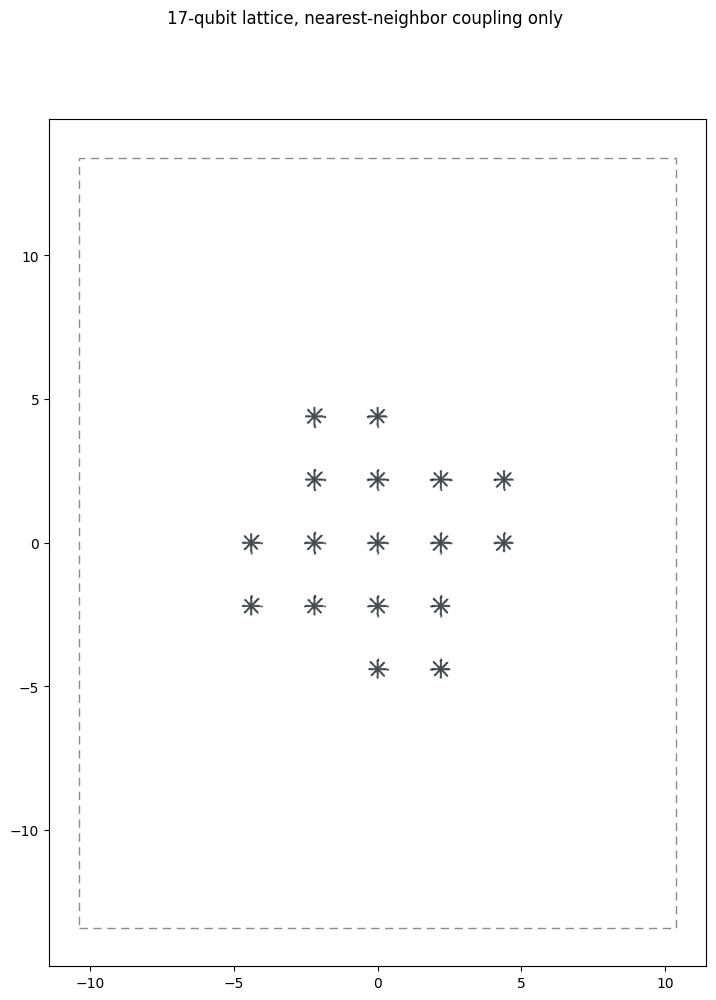

In [5]:
fig = qm.view(design)
fig.set_size_inches(10, 11)
fig.suptitle('17-qubit lattice, nearest-neighbor coupling only')
fig

### 4. Four readout feedlines

The real device splits its 17 qubits across **4 separate readout feedlines** rather than multiplexing everything onto one (confirmed in the published design's own routing parameters — a `READOUT_GROUPS` list of 4 groups of 4–5 qubits each). This notebook uses that same 4-feedline structure with its own quadrant grouping. Each readout resonator's `total_length` is set relative to that pair's actual straight-line distance (plus a margin and a small per-qubit stagger for frequency multiplexing) rather than one fixed value, since a fixed length far above the direct distance forces absurd wiggle counts for whichever qubit happens to sit close to its tap; a couple of pairs still need a slightly longer retry before the meander is geometrically feasible, so a short retry ladder covers those instead of hand-tuning each of the 17 individually.

In [6]:
READOUT_GROUPS = {
    'W': (['D7', 'X4', 'Z2', 'D8'], 'left'),
    'N': (['Z1', 'D1', 'D4', 'X2'], 'top'),
    'E': (['D2', 'X1', 'D3', 'Z3'], 'right'),
    'S': (['D5', 'X3', 'D6', 'D9', 'Z4'], 'bottom'),
}
EDGE = 2 * A + 2.5  # readout feedlines sit well inside the control-launchpad zone

for group_name, (members, side) in READOUT_GROUPS.items():
    n = len(members)
    half_span = A + 0.8
    if side in ('top', 'bottom'):
        coord = EDGE if side == 'top' else -EDGE
        xs = [-half_span + 2 * half_span * i / (n - 1) for i in range(n)]
        tap_pts = [(x, coord) for x in xs]
        orientation = '0' if side == 'top' else '180'
        lp_a, lp_b = (tap_pts[0][0] - 2.0, coord), (tap_pts[-1][0] + 2.0, coord)
        lp_orient_a, lp_orient_b = ('0', '180') if side == 'top' else ('180', '0')
    else:
        coord = EDGE if side == 'right' else -EDGE
        ys = [-half_span + 2 * half_span * i / (n - 1) for i in range(n)]
        tap_pts = [(coord, y) for y in ys]
        orientation = '270' if side == 'right' else '90'
        lp_a, lp_b = (coord, tap_pts[0][1] - 2.0), (coord, tap_pts[-1][1] + 2.0)
        lp_orient_a, lp_orient_b = ('270', '90') if side == 'right' else ('90', '270')

    for i, name in enumerate(members):
        CoupledLineTee(design, f'CLT_{name}', options=dict(
            pos_x=f'{tap_pts[i][0]}mm', pos_y=f'{tap_pts[i][1]}mm', orientation=orientation,
            coupling_length='150um', coupling_space='4um'))

    lp_in, lp_out = f'LP_ro_{group_name}_in', f'LP_ro_{group_name}_out'
    LaunchpadWirebond(design, lp_in, options=dict(pos_x=f'{lp_a[0]}mm', pos_y=f'{lp_a[1]}mm', orientation=lp_orient_a))
    LaunchpadWirebond(design, lp_out, options=dict(pos_x=f'{lp_b[0]}mm', pos_y=f'{lp_b[1]}mm', orientation=lp_orient_b))

    RouteStraight(design, f'Feed_{group_name}_in', options=dict(pin_inputs=dict(
        start_pin=dict(component=lp_in, pin='tie'), end_pin=dict(component=f'CLT_{members[0]}', pin='prime_start'))))
    for i in range(n - 1):
        RouteStraight(design, f'Feed_{group_name}_mid_{i}', options=dict(pin_inputs=dict(
            start_pin=dict(component=f'CLT_{members[i]}', pin='prime_end'),
            end_pin=dict(component=f'CLT_{members[i+1]}', pin='prime_start'))))
    RouteStraight(design, f'Feed_{group_name}_out', options=dict(pin_inputs=dict(
        start_pin=dict(component=f'CLT_{members[-1]}', pin='prime_end'), end_pin=dict(component=lp_out, pin='tie'))))

    for i, name in enumerate(members):
        col, row = QUBITS[name]
        qx, qy = col * A, row * A
        tx, ty = tap_pts[i]
        direct = math.hypot(tx - qx, ty - qy)
        length_mm = direct * 1.1 + 0.15 + 0.015 * i
        for attempt_length in (length_mm, length_mm + 0.3, length_mm + 0.6, length_mm + 0.9):
            try:
                RouteMeander(design, f'RO_{name}', options=dict(
                    pin_inputs=dict(start_pin=dict(component=name, pin='readout'), end_pin=dict(component=f'CLT_{name}', pin='second_end')),
                    total_length=f'{attempt_length}mm', fillet=BEND,
                    lead=dict(start_straight='250um', end_straight='250um'),
                    meander=dict(spacing='250um', asymmetry='0um'),
                ))
                break
            except Exception:
                if f'RO_{name}' in design.components:
                    design.delete_component(f'RO_{name}')
                continue
        else:
            raise RuntimeError(f'RO_{name}: meander failed at all attempted lengths')

design.rebuild()
print(f'Readout feedlines routed. Components: {len(design.components)}')

04:23PM 45s WARNING [connect_meandered]: RO_D7: reduced meander_number from 13.0 to 5.0 so each wiggle has room for the 0.05mm fillet (length_perp=0.05787mm). The requested meander.spacing packs more wiggles into this route than the available length_excess can support without producing sharp, unfileted kinks. Increase total_length, increase meander.spacing, or decrease fillet to avoid this adjustment.


04:23PM 45s WARNING [connect_meandered]: RO_X4: reduced meander_number from 10.0 to 0.0 so each wiggle has room for the 0.05mm fillet (length_perp=infmm). The requested meander.spacing packs more wiggles into this route than the available length_excess can support without producing sharp, unfileted kinks. Increase total_length, increase meander.spacing, or decrease fillet to avoid this adjustment.


04:23PM 45s ERROR [rebuild]: ERROR in building component name=RO_X4, error=index -3 is out of bounds for axis 0 with size 1


04:23PM 45s WARNING [connect_meandered]: RO_X4: reduced meander_number from 10.0 to 4.0 so each wiggle has room for the 0.05mm fillet (length_perp=0.05618mm). The requested meander.spacing packs more wiggles into this route than the available length_excess can support without producing sharp, unfileted kinks. Increase total_length, increase meander.spacing, or decrease fillet to avoid this adjustment.


04:23PM 45s WARNING [check_lengths]: For path table, component=RO_X4, key=trace has short segments that could cause issues with fillet. Values in (2-7)  are index(es) in shapely geometry.


...

04:23PM 47s WARNING [connect_meandered]: RO_X3: reduced meander_number from 19.0 to 3.0 so each wiggle has room for the 0.05mm fillet (length_perp=0.05433mm). The requested meander.spacing packs more wiggles into this route than the available length_excess can support without producing sharp, unfileted kinks. Increase total_length, increase meander.spacing, or decrease fillet to avoid this adjustment.


04:23PM 47s WARNING [connect_meandered]: RO_D6: reduced meander_number from 19.0 to 5.0 so each wiggle has room for the 0.05mm fillet (length_perp=0.06224mm). The requested meander.spacing packs more wiggles into this route than the available length_excess can support without producing sharp, unfileted kinks. Increase total_length, increase meander.spacing, or decrease fillet to avoid this adjustment.


04:23PM 47s WARNING [connect_meandered]: RO_D9: reduced meander_number from 10.0 to 2.0 so each wiggle has room for the 0.05mm fillet (length_perp=0.08402mm). The requested meander.spacing packs more wiggles into this route than the available length_excess can support without producing sharp, unfileted kinks. Increase total_length, increase meander.spacing, or decrease fillet to avoid this adjustment.


04:23PM 47s WARNING [connect_meandered]: RO_Z4: reduced meander_number from 10.0 to 2.0 so each wiggle has room for the 0.05mm fillet (length_perp=0.08286mm). The requested meander.spacing packs more wiggles into this route than the available length_excess can support without producing sharp, unfileted kinks. Increase total_length, increase meander.spacing, or decrease fillet to avoid this adjustment.


Readout feedlines routed. Components: 80


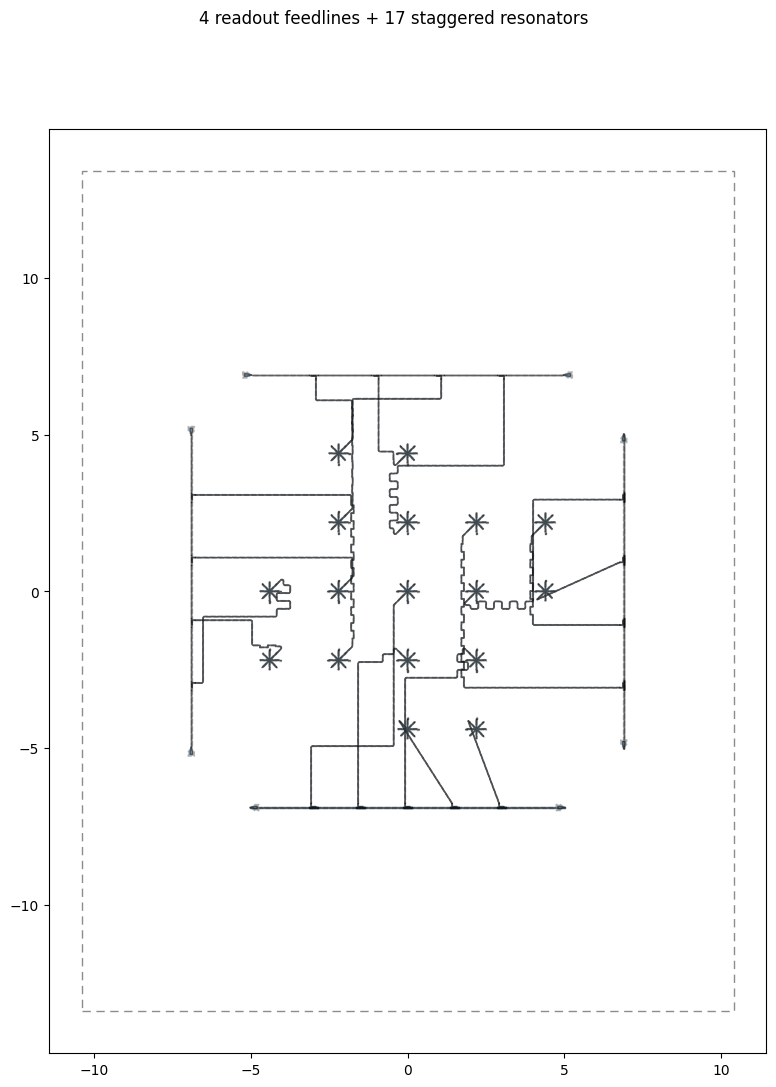

In [7]:
fig = qm.view(design)
fig.set_size_inches(11, 12)
fig.suptitle('4 readout feedlines + 17 staggered resonators')
fig

### 5. XY and Z control lines

Every qubit's XY line goes to a launchpad on whichever of the north/south edges its own `xy_arm` points toward, and Z goes to whichever of east/west its `z_arm` points toward — 34 launchpads spread across all 4 edges, grouped and evenly spaced the same way the readout taps are, rather than all 34 crammed onto one edge (a qubit on the far side of the cluster from a single shared launchpad row has no short path to it; spreading launchpads by direction keeps every route local). Each line is a `RouteAnchors` with a long lead — well past the whole qubit cluster before any bend is attempted — and `avoid_collision=True` so it actually routes around other components rather than through them. A handful of pin/launchpad geometries still don't fit the router's simple L/Z-shaped connection patterns even with that long lead; those fall back to a direct route, which is the source of most of what the DRC pass below flags.

In [8]:
CTRL_EDGE = 2 * A + 5.5

xy_groups = {'N': [], 'S': []}
z_groups = {'E': [], 'W': []}
for name, (col, row) in QUBITS.items():
    xy_groups['N' if row >= 0 else 'S'].append(name)
    z_groups['E' if col >= 0 else 'W'].append(name)

xy_launchpad_pos = {}
for side, members in xy_groups.items():
    members.sort(key=lambda n: QUBITS[n][0])
    n = len(members)
    half_span = A * (n - 1) / 2 + 0.5
    y = CTRL_EDGE if side == 'N' else -CTRL_EDGE
    for i, name in enumerate(members):
        x = -half_span + 2 * half_span * i / max(n - 1, 1) if n > 1 else 0.0
        xy_launchpad_pos[name] = (x, y, '270' if side == 'N' else '90')

z_launchpad_pos = {}
for side, members in z_groups.items():
    members.sort(key=lambda n: QUBITS[n][1])
    n = len(members)
    half_span = A * (n - 1) / 2 + 0.5
    x = CTRL_EDGE if side == 'E' else -CTRL_EDGE
    for i, name in enumerate(members):
        y = -half_span + 2 * half_span * i / max(n - 1, 1) if n > 1 else 0.0
        z_launchpad_pos[name] = (x, y, '180' if side == 'E' else '0')

for name in QUBITS:
    xy_lp, z_lp = f'LP_xy_{name}', f'LP_z_{name}'
    xlx, xly, xlo = xy_launchpad_pos[name]
    zlx, zly, zlo = z_launchpad_pos[name]
    LaunchpadWirebond(design, xy_lp, options=dict(pos_x=f'{xlx}mm', pos_y=f'{xly}mm', orientation=xlo))
    LaunchpadWirebond(design, z_lp, options=dict(pos_x=f'{zlx}mm', pos_y=f'{zly}mm', orientation=zlo))
    for pin, lp in [('xy', xy_lp), ('z', z_lp)]:
        route_name = f'{pin}_{name}'
        try:
            RouteAnchors(design, route_name, options=dict(
                pin_inputs=dict(start_pin=dict(component=name, pin=pin), end_pin=dict(component=lp, pin='tie')),
                lead=Dict(start_straight=f'{1.6*A}mm', end_straight='400um'),
                fillet=BEND, advanced=Dict(avoid_collision=True),
            ))
        except Exception:
            if route_name in design.components:
                design.delete_component(route_name)
            RouteStraight(design, route_name, options=dict(
                pin_inputs=dict(start_pin=dict(component=name, pin=pin), end_pin=dict(component=lp, pin='tie'))))

print(f'Control lines routed. Total components: {len(design.components)}')

04:23PM 47s ERROR [rebuild]: ERROR in building component name=z_Z1, error=Qiskit Metal - Designer Error: User action required. 
connect_simple() has failed. This might be due to one of two reasons. 1. Either one of the start point [-4.94569563  1.65430437] or the end point [-9.475  6.   ] provided are inside the bounding box of another QComponent. Please move the point, or setup a "lead" to exit the QComponent area. 2. none of the 4 routing possibilities of this algorithm (^|_, ^^|, __|, _|^) can complete. Please use Pathfinder instead


04:23PM 47s ERROR [rebuild]: ERROR in building component name=xy_D4, error=Qiskit Metal - Designer Error: User action required. 
connect_simple() has failed. This might be due to one of two reasons. 1. Either one of the start point [-4.94569563  4.94569563] or the end point [-6.9    9.475] provided are inside the bounding box of another QComponent. Please move the point, or setup a "lead" to exit the QComponent area. 2. none of the 4 routing possibilities of this algorithm (^|_, ^^|, __|, _|^) can complete. Please use Pathfinder instead


04:23PM 47s ERROR [rebuild]: ERROR in building component name=z_D4, error=Qiskit Metal - Designer Error: User action required. 
connect_simple() has failed. This might be due to one of two reasons. 1. Either one of the start point [-4.94569563 -0.54569563] or the end point [-9.475  3.6  ] provided are inside the bounding box of another QComponent. Please move the point, or setup a "lead" to exit the QComponent area. 2. none of the 4 routing possibilities of this algorithm (^|_, ^^|, __|, _|^) can complete. Please use Pathfinder instead


04:23PM 48s ERROR [rebuild]: ERROR in building component name=xy_X2, error=Qiskit Metal - Designer Error: User action required. 
connect_simple() has failed. This might be due to one of two reasons. 1. Either one of the start point [2.74569563 4.94569563] or the end point [0.    9.475] provided are inside the bounding box of another QComponent. Please move the point, or setup a "lead" to exit the QComponent area. 2. none of the 4 routing possibilities of this algorithm (^|_, ^^|, __|, _|^) can complete. Please use Pathfinder instead


04:23PM 48s ERROR [rebuild]: ERROR in building component name=z_X2, error=Qiskit Metal - Designer Error: User action required. 
connect_simple() has failed. This might be due to one of two reasons. 1. Either one of the start point [-2.74569563  4.94569563] or the end point [9.475 4.6  ] provided are inside the bounding box of another QComponent. Please move the point, or setup a "lead" to exit the QComponent area. 2. none of the 4 routing possibilities of this algorithm (^|_, ^^|, __|, _|^) can complete. Please use Pathfinder instead


...

04:23PM 50s ERROR [rebuild]: ERROR in building component name=z_D6, error=Qiskit Metal - Designer Error: User action required. 
connect_simple() has failed. This might be due to one of two reasons. 1. Either one of the start point [4.94569563 0.54569563] or the end point [ 9.475 -4.6  ] provided are inside the bounding box of another QComponent. Please move the point, or setup a "lead" to exit the QComponent area. 2. none of the 4 routing possibilities of this algorithm (^|_, ^^|, __|, _|^) can complete. Please use Pathfinder instead


04:23PM 51s ERROR [rebuild]: ERROR in building component name=z_D9, error=Qiskit Metal - Designer Error: User action required. 
connect_simple() has failed. This might be due to one of two reasons. 1. Either one of the start point [ 2.74569563 -1.65430437] or the end point [  9.475 -11.5  ] provided are inside the bounding box of another QComponent. Please move the point, or setup a "lead" to exit the QComponent area. 2. none of the 4 routing possibilities of this algorithm (^|_, ^^|, __|, _|^) can complete. Please use Pathfinder instead


04:23PM 51s ERROR [rebuild]: ERROR in building component name=xy_Z4, error=Qiskit Metal - Designer Error: User action required. 
connect_simple() has failed. This might be due to one of two reasons. 1. Either one of the start point [ 4.94569563 -7.14569563] or the end point [ 6.    -9.475] provided are inside the bounding box of another QComponent. Please move the point, or setup a "lead" to exit the QComponent area. 2. none of the 4 routing possibilities of this algorithm (^|_, ^^|, __|, _|^) can complete. Please use Pathfinder instead


04:23PM 51s ERROR [rebuild]: ERROR in building component name=z_Z4, error=Qiskit Metal - Designer Error: User action required. 
connect_simple() has failed. This might be due to one of two reasons. 1. Either one of the start point [ 4.94569563 -1.65430437] or the end point [ 9.475 -9.2  ] provided are inside the bounding box of another QComponent. Please move the point, or setup a "lead" to exit the QComponent area. 2. none of the 4 routing possibilities of this algorithm (^|_, ^^|, __|, _|^) can complete. Please use Pathfinder instead


Control lines routed. Total components: 148


### 6. Test structures

A standalone test junction and a standalone test resonator, tucked in an empty corner and not connected to the active circuit — common on real dies for process monitoring (junction resistance, resonator loss/frequency) independent of the qubits themselves.

In [9]:
TransmonStar(design, 'TestJunction', options=dict(
    pos_x=f'{2*A+2}mm', pos_y=f'{2*A+4}mm', num_points=8,
    arm_length='300um', arm_width='20um', arm_gap='10um', junction_arm_index=4,
))
OpenToGround(design, 'TestResOpen1', options=dict(pos_x=f'{2*A+1.5}mm', pos_y=f'{2*A+2.5}mm', orientation='180'))
OpenToGround(design, 'TestResOpen2', options=dict(pos_x=f'{2*A+3.5}mm', pos_y=f'{2*A+2.5}mm', orientation='0'))
RouteMeander(design, 'TestResonator', options=dict(
    pin_inputs=dict(start_pin=dict(component='TestResOpen1', pin='open'), end_pin=dict(component='TestResOpen2', pin='open')),
    total_length='4mm', fillet=BEND,
    lead=dict(start_straight='100um', end_straight='100um'),
    meander=dict(spacing='200um', asymmetry='0um'),
))

print(f'Test structures added. Total components: {len(design.components)}')

Test structures added. Total components: 152


### 7. Completed layout

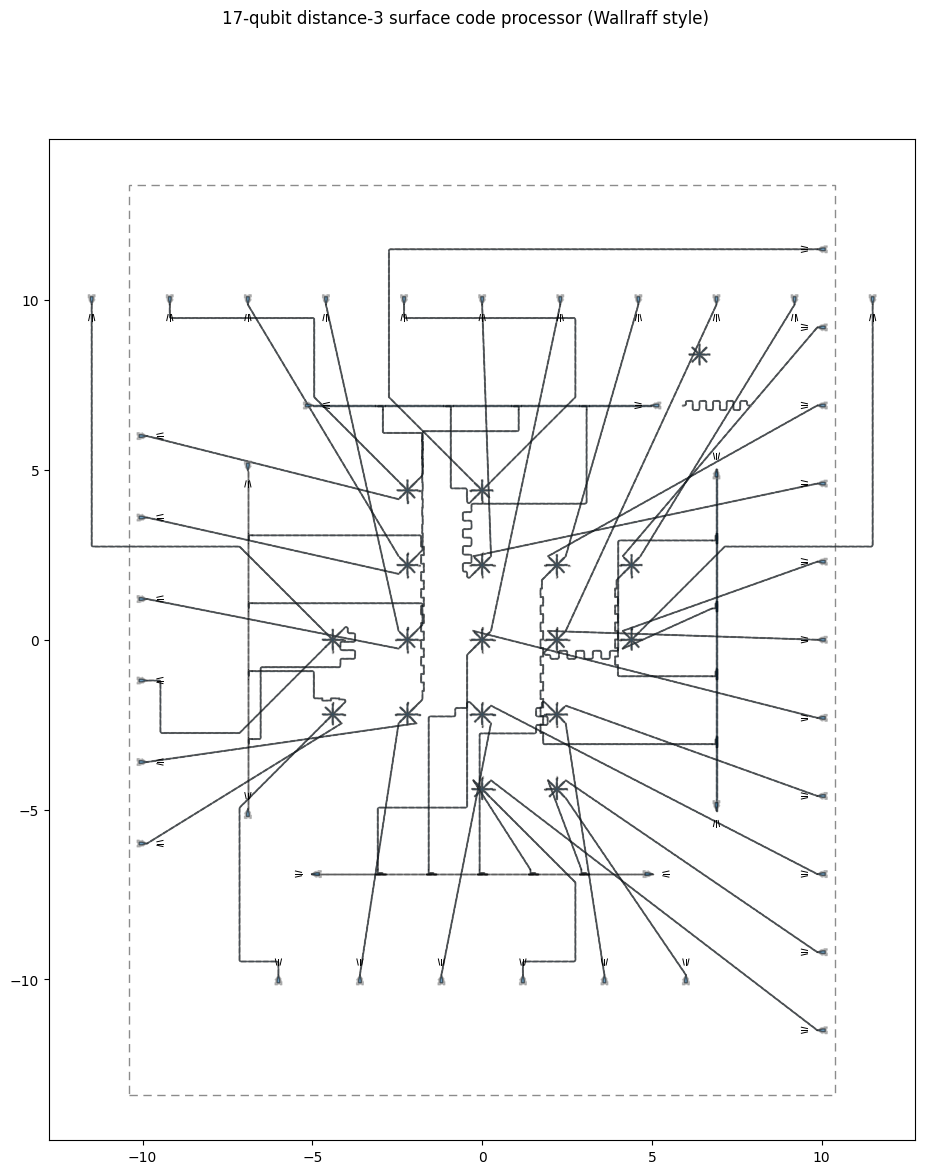

In [10]:
fig = qm.view(design)
fig.set_size_inches(13, 13)
ax = fig.gca()

# Cosmetic wirebond marks at every edge launchpad -- a short comb of
# lines past the pad's outer tip, purely visual (not qgeometry / not on
# any fab layer), matching the hash-mark wirebond fans in the reference
# figure's launchpad rows.
for lp_name in [c for c in design.components if c.startswith('LP_')]:
    comp = design.components[lp_name]
    ori = float(comp.options.orientation)
    x0, y0 = float(comp.options.pos_x[:-2]), float(comp.options.pos_y[:-2])
    theta = math.radians(ori)
    ux, uy = math.cos(theta), math.sin(theta)
    px, py = -uy, ux
    base = 0.32
    for k in (-1, 0, 1):
        x1, y1 = x0 + ux * base + px * (0.05 * k), y0 + uy * base + py * (0.05 * k)
        x2, y2 = x0 + ux * (base + 0.18) + px * (0.09 * k), y0 + uy * (base + 0.18) + py * (0.09 * k)
        ax.plot([x1, x2], [y1, y2], color='black', linewidth=0.7, zorder=50)

fig.suptitle('17-qubit distance-3 surface code processor (Wallraff style)')
fig

### 8. Design rule check

`qiskit_metal.validation` runs a set of geometric design rules (metal overlap, CPW gap, short segments vs. fillet radius, chip bounds, ground continuity) and reports every violation with its location. This chip is a topology and placement illustration, not a routed, fabrication-ready mask. Most of what remains here traces back to two things: (1) a handful of the 34 control lines whose pin/launchpad geometry doesn't fit `RouteAnchors`' simple L/Z-shaped connection patterns even with a long lead clear of the cluster, so they fall back to a direct route and can cross other components; and (2) a few of the 17 individually-staggered readout meanders whose wiggle count, once auto-reduced to fit the fillet radius, still leaves segments shorter than the rule's threshold. A production tapeout would resolve both through iterative, hand-tuned or waypoint-based routing (or true multi-object collision-avoidance routing) per line; showing them here, rather than silently choosing parameters that happen to hide them, is what DRC is for.

In [11]:
result = validate(design)
print(result.report())

328 finding(s) from 7 rule(s): 123 error(s), 205 warning(s)
  [error] metal-overlap: CLT_D8 and z_D4 overlap by 191 um^2 of metal on layer 1  @ (-6.9000, 2.9346)
  [error] metal-overlap: Feed_W_in and xy_X4 overlap by 141 um^2 of metal on layer 1  @ (-6.9000, -4.7000)
  [error] metal-overlap: Feed_W_in and z_X4 overlap by 118 um^2 of metal on layer 1  @ (-6.9000, -4.1653)
  [error] metal-overlap: Feed_W_in and z_D8 overlap by 101 um^2 of metal on layer 1  @ (-6.9000, -3.1731)
  [error] metal-overlap: Feed_W_mid_0 and z_D7 overlap by 141 um^2 of metal on layer 1  @ (-6.9000, -2.5000)
  [error] metal-overlap: Feed_W_mid_1 and z_Z2 overlap by 102 um^2 of metal on layer 1  @ (-6.9000, 0.6147)
  [error] metal-overlap: Feed_W_mid_2 and xy_D7 overlap by 141 um^2 of metal on layer 1  @ (-6.9000, 2.5000)
  [error] metal-overlap: RO_D7 and z_D7 overlap by 283 um^2 of metal on layer 1  @ (-5.2081, -0.8081)
  [error] metal-overlap: RO_D7 and RO_X4 overlap by 100 um^2 of metal on layer 1  @ (-6.524

### 9. Export to GDSII

In [12]:
gds_renderer = design.renderers.gds
gds_renderer.options.short_segments_to_not_fillet = 'False'
gds_renderer.export_to_gds('walraff_17qubit_surface_code.gds')
print('Layout exported to GDSII.')

04:23PM 52s WARNING [import_junction_gds_file]: Not able to find file:"../resources/Fake_Junctions.GDS".  Not used to replace junction. Checked directory:"/Users/zlatkominev/CODE_REPOS/quantum_hardware_all/resources".


04:23PM 52s WARNING [_cheese_buffer_maker]: The bounding box for no-cheese is outside of chip size.
Bounding box for chip is (-10.4, -13.4, 10.4, 13.4).
Bounding box with no_cheese buffer is (-11.623000000000001, -11.623000000000001, 11.623000000000001, 11.623000000000001).


Layout exported to GDSII.


## References

1. Krinner, S. *et al.* Realizing repeated quantum error correction in a distance-three surface code. *Nature* **605**, 669–674 (2022).
2. Besedin, I. & Kerschbaum, M. Realizing Lattice Surgery on Two Distance-Three Repetition Codes with Superconducting Qubits. [arXiv:2501.04612](https://arxiv.org/abs/2501.04612) (2025).